# Exploración de los datos

Antes de crear las tablas y escribir el SQL quise mirar los 5 archivos para entender qué trae cada uno y qué problemas tienen. Lo que encuentro acá es lo que después limpio en SQL.

1. Carga de los archivos
2. Catálogos
3. Portafolio local (COP)
4. Portafolio internacional (USD)
5. Local + internacional
6. Resumen de problemas

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Carga de los archivos

Leo todo como texto para que pandas no me cambie nada (por ejemplo, que no convierta los `None` en vacíos ni los IDs de cliente en números).

In [2]:
archivos = ["cat_perfil_riesgo", "catalogo_activos", "catalogo_banca",
            "historico_aba_macroactivos", "historico_aba_usd_internacional"]

datos = {}
for nombre in archivos:
    datos[nombre] = pd.read_csv(DATA_DIR / f"{nombre}.csv", dtype=str, keep_default_na=False)
    print(nombre, datos[nombre].shape)

perfil = datos["cat_perfil_riesgo"]
activos = datos["catalogo_activos"]
banca = datos["catalogo_banca"]
macro = datos["historico_aba_macroactivos"]
usd = datos["historico_aba_usd_internacional"]

cat_perfil_riesgo (4, 2)
catalogo_activos (20, 2)
catalogo_banca (6, 2)
historico_aba_macroactivos (6694, 11)
historico_aba_usd_internacional (5750, 12)


## 2. Catálogos

Son las tablas que traducen los códigos (1468, PF, 1014...) a nombres que sí se entienden.

In [3]:
display(perfil)
display(banca)
print("Filas repetidas en catalogo_banca:", banca.duplicated().sum())

,cod_perfil_riesgo,perfil_riesgo
0,1469,AGRESIVO
1,1468,MODERADO
2,1466,SIN DEFINIR
3,1467,CONSERVADOR


,cod_banca,banca
0,PR,Privada
1,PN,Personal
2,PF,Preferencial
3,EG,Empresas
4,PY,Pymes
5,PR,Privada


Filas repetidas en catalogo_banca: 1


In [4]:
display(activos.sort_values("cod_activo"))
print("Activos con el nombre repetido:")
display(activos[activos.duplicated("activo", keep=False)])

,activo,cod_activo
0,CDT BANCOLOMBIA B360,1000
1,CDT TUYA TF B360,1001
2,CELSIA,1002
3,CEMARGOS,1003
4,ECOPETROL,1004
5,ETB,1005
6,Fiducuenta,1007
7,Fidurenta,1008
8,Fondo Cerrado Renta Fija IV,1009
9,Fondo Cerrado Renta Fija V,1010


Activos con el nombre repetido:


,activo,cod_activo
3,CEMARGOS,1003
12,CEMARGOS,1013


**Lo que veo:**
- En `catalogo_banca` la fila `PR, Privada` está dos veces.
- En `catalogo_activos` CEMARGOS aparece con dos códigos (1003 y 1013).
- PFCEMARGOS tiene el código 1115, que se sale de la secuencia (los demás van de 1000 a 1020). Más abajo reviso contra los datos cuál es el código que realmente se usa.

## 3. Portafolio local: `historico_aba_macroactivos`

ABA son los activos bajo administración. Cada fila es el saldo en pesos que tiene un cliente en un activo en un día.

In [5]:
display(macro.head())
print("Filas:", len(macro))
print("Filas duplicadas exactas:", macro.duplicated().sum())

macro = macro.drop_duplicates()
print("Filas sin duplicados:", len(macro))

,ingestion_year,ingestion_month,ingestion_day,id_sistema_cliente,macroactivo,cod_activo,aba,cod_perfil_riesgo,cod_banca,year,month
0,2023,12,20,1.00114E+12,Renta Variable,1004,2370000,1466,PN,2023,12
1,2024,2,1,10020203023,FICs,None,445708066,1468,PR,2024,2
2,2024,3,22,10032184607,Renta Variable,1011,8288500,1468,PN,2024,3
3,2024,2,27,1.00902E+11,FICs,1019,1049541789,1467,PF,2024,2
4,2023,12,11,1.00103E+12,Renta Variable,1004,1232500,1468,PN,2023,12


Filas: 6694
Filas duplicadas exactas: 783
Filas sin duplicados: 5911


### Filas con formato raro

Reviso que cada columna tenga el tipo de valor que debería tener.

In [6]:
bancas = ["PN", "PR", "PF", "PY", "EG"]
perfiles = ["1466", "1467", "1468", "1469", "None"]
macroactivos = ["Renta Variable", "Renta Fija", "FICs"]

def es_numero(columna):
    return pd.to_numeric(columna, errors="coerce").notna()

fila_ok = (
    pd.to_numeric(macro["ingestion_day"], errors="coerce").between(1, 31)
    & pd.to_numeric(macro["ingestion_month"], errors="coerce").between(1, 12)
    & macro["year"].isin(["2023", "2024"])
    & (macro["month"] == macro["ingestion_month"])
    & (pd.to_numeric(macro["id_sistema_cliente"], errors="coerce") >= 1e9)
    & macro["macroactivo"].isin(macroactivos)
    & (es_numero(macro["cod_activo"]) | (macro["cod_activo"] == "None"))
    & es_numero(macro["aba"])
    & macro["cod_perfil_riesgo"].isin(perfiles)
    & macro["cod_banca"].isin(bancas)
)

print("Filas con algún problema de formato:", (~fila_ok).sum(), "de", len(macro))
macro[~fila_ok].head(8)

Filas con algún problema de formato: 51 de 5911


,ingestion_year,ingestion_month,ingestion_day,id_sistema_cliente,macroactivo,cod_activo,aba,cod_perfil_riesgo,cod_banca,year,month
7,2023,12,5,1.00114E+12,,1004,2545000,1466,PN,2023,12
8,2024,4,15,10032184607,Renta Variable,1022,3287434.68,1468,,2024,4
22,2024,,27,10098522488,Renta Variable,1004,2992500,1466,PN,2024,3
27,2024,4,1,10026419826,Renta Variable,1005,90535,1466,,2024,4
55,2024,3,14,,890112256,FICs,1008,22350729.74,1468,PR,2024
63,2024,1,24,10039553126,FICs,1018,641420.06,,PN,2024,1
64,2024,1,16,10039616197,Renta Variable,,2375000,1466,PN,2024,1
70,2024,,23,10021382511,Renta Variable,1004,2340000,1466,PN,2024,2


**Lo que veo:** son muy pocas filas (menos del 1%). En algunas falta un campo y en otras los valores quedaron corridos de columna (por ejemplo, un pedazo del ID del cliente en la columna de macroactivo).

Decido no intentar repararlas porque tendría que adivinar valores. En SQL las voy a dejar en una tabla aparte de filas rechazadas, para que no se pierdan sin dejar rastro. De acá en adelante sigo solo con las filas buenas.

In [7]:
m = macro[fila_ok].copy()
m["aba"] = m["aba"].astype(float)
m["fecha"] = pd.to_datetime(dict(year=m["ingestion_year"].astype(int),
                                 month=m["ingestion_month"].astype(int),
                                 day=m["ingestion_day"].astype(int)))

print("Desde", m["fecha"].min().date(), "hasta", m["fecha"].max().date())
print("Fechas distintas:", m["fecha"].nunique())
print("Días de la semana:", sorted(m["fecha"].dt.dayofweek.unique().tolist()), "(0 = lunes, 4 = viernes)")
print("Filas rechazadas en la última fecha:",
      ((macro.loc[~fila_ok, "ingestion_year"] == "2024") & (macro.loc[~fila_ok, "ingestion_month"] == "5")
       & (macro.loc[~fila_ok, "ingestion_day"] == "15")).sum())

Desde 2023-11-23 hasta 2024-05-15
Fechas distintas: 112
Días de la semana: [0, 1, 2, 3, 4] (0 = lunes, 4 = viernes)
Filas rechazadas en la última fecha: 0


Hay datos de 112 días, solo de lunes a viernes, entre noviembre de 2023 y mayo de 2024. Las columnas `year` y `month` repiten lo mismo que la fecha de ingesta, así que no las necesito. Ninguna de las filas rechazadas es de la última fecha, entonces no afectan el portafolio que se va a mostrar en la aplicación.

### Clientes

In [8]:
ids = m["id_sistema_cliente"].drop_duplicates()
con_e = ids[ids.str.contains("E+", regex=False)]
print("Clientes distintos:", len(ids))
print("IDs en notación científica:", len(con_e))
print(sorted(con_e)[:5])

print()
print("Clientes con menos filas:")
print(m["id_sistema_cliente"].value_counts().tail(3))
display(m[m["id_sistema_cliente"] == "1002203023"][["fecha", "id_sistema_cliente", "cod_activo", "aba", "cod_perfil_riesgo", "cod_banca"]])

# ¿el cliente 10020203023 tiene el activo 1001 ese mismo día?
print("Filas de 10020203023 con el activo 1001 el 2024-03-20:",
      len(m[(m["id_sistema_cliente"] == "10020203023") & (m["cod_activo"] == "1001") & (m["fecha"] == "2024-03-20")]))

Clientes distintos: 30
IDs en notación científica: 11
['1.00101E+12', '1.00103E+12', '1.00105E+12', '1.00109E+12', '1.00114E+12']

Clientes con menos filas:
id_sistema_cliente
10041560001    109
10039553126    109
1002203023       1
Name: count, dtype: int64


,fecha,id_sistema_cliente,cod_activo,aba,cod_perfil_riesgo,cod_banca
114,2024-03-20,1002203023,1001,"667,131,500.00",1468,PR


Filas de 10020203023 con el activo 1001 el 2024-03-20: 0


**Lo que veo:**
- Varios IDs vienen en notación científica (`1.00114E+12`). Parece que el archivo pasó por Excel y este guardó el número redondeado, así que los últimos dígitos se perdieron y no hay forma de recuperarlos. Los dejo como vienen y los trato como un cliente cada uno, pero es una limitación: esos clientes no los puedo cruzar con el portafolio internacional.
- Casi todos los clientes tienen más de 100 filas, pero el ID `1002203023` solo aparece una vez. Es igual a `10020203023` pero con un cero menos, y justo es el CDT que a ese cliente le falta ese día. Lo tomo como un error de digitación y lo corrijo.

In [9]:
m["id_sistema_cliente"] = m["id_sistema_cliente"].replace({"1002203023": "10020203023"})
print("Clientes distintos después de corregir:", m["id_sistema_cliente"].nunique())

Clientes distintos después de corregir: 29


### Activos

In [10]:
codigos_datos = set(m["cod_activo"])
codigos_catalogo = set(activos["cod_activo"])
print("Códigos en los datos que no están en el catálogo:", sorted(codigos_datos - codigos_catalogo))
print("Códigos del catálogo que nunca aparecen en los datos:", sorted(codigos_catalogo - codigos_datos))

# 1007 vs 10007: días en que un cliente tiene los dos códigos
f = m[m["cod_activo"].isin(["1007", "10007"])]
dos = f.groupby(["id_sistema_cliente", "fecha"]).filter(lambda g: g["cod_activo"].nunique() > 1)
print()
print("Filas con 10007:", (m["cod_activo"] == "10007").sum(), "| filas con 1007:", (m["cod_activo"] == "1007").sum())
display(dos[["id_sistema_cliente", "fecha", "cod_activo", "aba"]].sort_values(["id_sistema_cliente", "fecha"]))

# 1015 y 1003 en el único cliente que los tiene
c = m[m["cod_activo"].isin(["1015", "1003"])]
display(c.groupby("cod_activo")["fecha"].agg(["min", "max", "count"]))

Códigos en los datos que no están en el catálogo: ['10007', '1015', '1022', 'None']
Códigos del catálogo que nunca aparecen en los datos: ['1013', '1115']

Filas con 10007: 1111 | filas con 1007: 7


,id_sistema_cliente,fecha,cod_activo,aba
303,1.00114E+12,2024-01-19,1007,"10,249.14"
595,1.00114E+12,2024-01-19,10007,"10,249.14"
309,1.009E+11,2024-05-15,1007,"104,552,952.70"
4813,1.009E+11,2024-05-15,10007,"104,552,952.70"


,min,max,count
cod_activo,,,
1003,2024-05-06,2024-05-15,5
1015,2023-11-23,2024-05-03,106


**Lo que veo:**
- `10007` es Fiducuenta (`1007`) con un cero de más: en un mismo cliente los dos códigos se van alternando y, los días en que aparecen los dos, el valor es exactamente el mismo. Como uno de esos días es la última fecha, si no lo corrijo el portafolio de ese cliente contaría dos veces la misma plata.
- `1015` es PFCEMARGOS (el catálogo dice 1115). La serie de 1015 termina el 3 de mayo de 2024 y el siguiente día hábil empieza CEMARGOS (1003) con casi el mismo valor. Buscando encontré que en esas fechas Cementos Argos convirtió sus acciones preferenciales en ordinarias, así que los datos sí cuadran con lo que pasó en el mercado.
- Por lo mismo, CEMARGOS es 1003 y el 1013 del catálogo sobra.
- `1022` y `None` no están en el catálogo. Como son saldos reales no los borro, los voy a mostrar como "No identificado".

### Saltos raros en los valores

Busco valores que cambian mucho un solo día y al día siguiente vuelven a lo normal.

In [11]:
# primero unifico el código de Fiducuenta y quito las filas repetidas por cliente, activo y fecha
m["cod_activo"] = m["cod_activo"].replace({"10007": "1007"})
llave = ["id_sistema_cliente", "cod_activo", "fecha"]

repetidas = m[m.duplicated(llave, keep=False)].sort_values(llave)
display(repetidas[llave + ["aba"]])

# me quedo con el valor que más se parece al resto de la serie
mediana = m.groupby(["id_sistema_cliente", "cod_activo"])["aba"].transform("median")
m["distancia"] = (m["aba"] - mediana).abs()
m = m.sort_values(llave + ["distancia"]).drop_duplicates(llave).drop(columns="distancia")

,id_sistema_cliente,cod_activo,fecha,aba
303,1.00114E+12,1007,2024-01-19,"10,249.14"
595,1.00114E+12,1007,2024-01-19,"10,249.14"
309,1.009E+11,1007,2024-05-15,"104,552,952.70"
4813,1.009E+11,1007,2024-05-15,"104,552,952.70"
26,1.009E+11,1019,2024-05-03,"2,280,623.29"
5716,1.009E+11,1019,2024-05-03,"22,380,623.29"


In [12]:
grupo = m.groupby(["id_sistema_cliente", "cod_activo"])["aba"]
m["aba_ayer"] = grupo.shift(1)
m["aba_manana"] = grupo.shift(-1)

# el valor es el doble del de ayer y del de mañana
doble = (m["aba"] / m["aba_ayer"]).between(1.8, 2.2) & (m["aba"] / m["aba_manana"]).between(1.8, 2.2)

# el valor multiplicado por 10 (o por 100) da casi lo mismo que ayer y que mañana
digito = pd.Series(False, index=m.index)
for factor in [10, 100]:
    digito = digito | ((m["aba"] * factor / m["aba_ayer"]).between(0.95, 1.05)
                       & (m["aba"] * factor / m["aba_manana"]).between(0.95, 1.05))

columnas = ["id_sistema_cliente", "cod_activo", "fecha", "aba_ayer", "aba", "aba_manana"]
print("Valores que se duplican un solo día:")
display(m.loc[doble, columnas])
print("Valores que pierden uno o dos dígitos un solo día:")
display(m.loc[digito, columnas])

m["aba_corregido"] = m["aba"]
m.loc[doble, "aba_corregido"] = m.loc[doble, "aba"] / 2
m.loc[digito, "aba_corregido"] = m.loc[digito, "aba_ayer"]

Valores que se duplican un solo día:


,id_sistema_cliente,cod_activo,fecha,aba_ayer,aba,aba_manana
2077,10020203023,1000,2024-01-08,"367,114,300.00","734,575,100.00","367,341,800.00"
6650,10020203023,1000,2024-03-25,"365,264,400.00","731,382,900.00","365,742,600.00"
6285,10020203023,1000,2024-03-29,"365,960,100.00","732,223,800.00","366,365,900.00"
3433,10020203023,1001,2024-01-08,"672,676,000.00","1,347,640,000.00","673,919,500.00"
4060,10020203023,1001,2024-03-25,"667,511,500.00","1,336,494,000.00","668,341,000.00"
2960,10020203023,1001,2024-03-29,"668,735,000.00","1,338,042,000.00","669,835,500.00"


Valores que pierden uno o dos dígitos un solo día:


,id_sistema_cliente,cod_activo,fecha,aba_ayer,aba,aba_manana
35,1.0089E+11,1019,2024-02-22,"146,423,248.10","1,464,638.50","146,504,829.40"
20,10038643094,1018,2024-02-01,"85,569,357.38","8,564,476.19","85,687,818.86"


In [13]:
# un cambio que NO es error: el Fondo Cerrado Renta Fija V (1010) y Fiducuenta (1007) del mismo cliente
c = m[(m["id_sistema_cliente"] == "10020203023") & m["cod_activo"].isin(["1010", "1007"])
      & m["fecha"].between("2024-02-15", "2024-02-22")]
(c.pivot(index="fecha", columns="cod_activo", values="aba") / 1e6).round(1)

cod_activo,1007,1010
fecha,,
2024-02-15,1.90,151.50
2024-02-16,1.90,151.50
2024-02-19,1.90,151.70
2024-02-20,150.50,3.10
2024-02-21,150.50,3.10
2024-02-22,150.60,3.10


**Lo que veo:**
- Hay 6 valores que se duplican exactamente un día y al otro día vuelven al valor normal. Todos son de los CDTs de un mismo cliente y caen el 8 de enero, el 25 de marzo y el 29 de marzo de 2024, que son festivos en Colombia. Los tomo como error y los divido por 2.
- Hay 2 valores a los que les falta un dígito un solo día. Los reemplazo por el valor del día anterior.
- En cambio, hay saltos que se mantienen y que no son errores sino movimientos del cliente. En la tabla de arriba (en millones) se ve cómo el fondo cerrado baja y esa misma plata aparece en Fiducuenta. Esos no los toco. Me parece información útil para un gerente comercial, porque es plata que quedó en liquidez y se podría reinvertir.

### Portafolio local a la última fecha

In [14]:
ultima = m.groupby("id_sistema_cliente")["fecha"].transform("max")
foto = m[m["fecha"] == ultima].copy()
print("¿Todos los clientes tienen datos en la última fecha?", (ultima == m["fecha"].max()).all())

foto["banca"] = foto["cod_banca"].map(banca.drop_duplicates().set_index("cod_banca")["banca"])
foto["perfil"] = foto["cod_perfil_riesgo"].map(perfil.set_index("cod_perfil_riesgo")["perfil_riesgo"]).fillna("SIN DEFINIR")

print("Fecha:", foto["fecha"].max().date(), "| clientes:", foto["id_sistema_cliente"].nunique(),
      "| posiciones:", len(foto), "| total en millones de COP:", round(foto["aba_corregido"].sum() / 1e6, 1))

for columna in ["macroactivo", "banca", "perfil"]:
    t = foto.groupby(columna).agg(clientes=("id_sistema_cliente", "nunique"), millones_cop=("aba_corregido", "sum"))
    t["millones_cop"] = t["millones_cop"] / 1e6
    t["porcentaje"] = (t["millones_cop"] / t["millones_cop"].sum() * 100).round(1)
    display(t.sort_values("millones_cop", ascending=False))

¿Todos los clientes tienen datos en la última fecha? True
Fecha: 2024-05-15 | clientes: 29 | posiciones: 52 | total en millones de COP: 5096.2


,clientes,millones_cop,porcentaje
macroactivo,,,
FICs,16,"3,947.07",77.50
Renta Fija,1,"1,025.87",20.10
Renta Variable,16,123.26,2.40


,clientes,millones_cop,porcentaje
banca,,,
Privada,2,"2,002.06",39.30
Preferencial,3,"1,210.12",23.70
Empresas,1,"1,078.00",21.20
Pymes,2,535.16,10.50
Personal,21,270.87,5.30


,clientes,millones_cop,porcentaje
perfil,,,
CONSERVADOR,4,"2,811.86",55.20
MODERADO,9,"2,112.97",41.50
SIN DEFINIR,15,163.43,3.20
AGRESIVO,2,7.95,0.20


Los 3 clientes más grandes tienen el 78.1 % del total


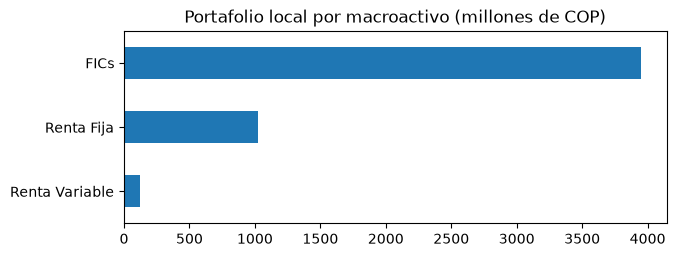

In [15]:
por_cliente = foto.groupby("id_sistema_cliente")["aba_corregido"].sum().sort_values(ascending=False) / 1e6
print("Los 3 clientes más grandes tienen el", round(por_cliente.head(3).sum() / por_cliente.sum() * 100, 1), "% del total")

t = foto.groupby("macroactivo")["aba_corregido"].sum().sort_values() / 1e6
t.plot.barh(figsize=(7, 2.5), title="Portafolio local por macroactivo (millones de COP)")
plt.ylabel("")
plt.show()

**Lo que veo:**
- Al 15 de mayo de 2024 hay 29 clientes con unos 5.100 millones de pesos. Casi todo está en FICs.
- Está muy concentrado: 3 clientes tienen cerca del 78% del total.
- Banca Personal tiene la mayoría de los clientes pero muy poca plata en el portafolio local.
- Casi la mitad de los clientes tiene el perfil de riesgo SIN DEFINIR (uno viene con `None`, que dejo también como SIN DEFINIR).

## 4. Portafolio internacional: `historico_aba_usd_internacional`

Cada fila es una posición de un cliente en su cuenta de inversión en el exterior, con el valor en dólares.

In [16]:
display(usd.head(4).drop(columns=["ingestion_year", "ingestion_month", "ingestion_day"]))

print("Nombres de activo con espacios de sobra:", (usd["nombre_activo"] != usd["nombre_activo"].str.strip()).sum())
usd["nombre_activo"] = usd["nombre_activo"].str.strip()

print("Filas duplicadas exactas:", usd.duplicated().sum())
usd = usd.drop_duplicates()
print("Filas sin duplicados:", len(usd))

print("Textos 'None' y 'nan' en simbol:", usd["simbol"].isin(["None", "nan"]).sum())
print("Fechas de vencimiento iguales a 1/01/1900:", (usd["fecha_vencimiento"] == "1/01/1900").sum())
print("Filas con 'Liquidez' en la columna isin:", (usd["isin"] == "Liquidez").sum())

,id_sistema_cliente,simbol,cusip,isin,nombre_activo,cantidad,valor_mercado,fecha_vencimiento,tasa_cupon
0,1004870235,None,L4058R217,LU0109391861,FRANKLIN U.S. OPPORTUNITIES FUND CLASS A (ACC)...,6249.938,190810.61,1/01/1900,0
1,1004870235,None,L1R49P707,LU1196525536,BGF CONTINENTAL EUROPEAN FLEXIBLE FUND CLASS A...,5973.45,155668.11,1/01/1900,0
2,1004870235,DLPG,MONEYMRKT,Liquidez,BNY MELLON US DOLLAR LIQD SERV,0,17736.4,1/01/1900,0
3,1004870235,None,L8145U257,LU0181495838,SCHRODER ISF EMERGING ASIA FUND CLASS A (USD),506.64,23989.96,1/01/1900,0


Nombres de activo con espacios de sobra: 4498
Filas duplicadas exactas: 543
Filas sin duplicados: 5207
Textos 'None' y 'nan' en simbol: 2158
Fechas de vencimiento iguales a 1/01/1900: 3916
Filas con 'Liquidez' en la columna isin: 755


In [17]:
fila_ok = (
    usd["id_sistema_cliente"].str.isdigit()
    & pd.to_numeric(usd["valor_mercado"], errors="coerce").notna()
    & usd["fecha_vencimiento"].str.contains("/")
)
print("Filas con algún problema de formato:", (~fila_ok).sum())
display(usd.loc[~fila_ok, ["id_sistema_cliente", "simbol", "isin", "nombre_activo", "cantidad", "valor_mercado"]])

u = usd[fila_ok].copy()
u["valor"] = u["valor_mercado"].astype(float)
u["fecha"] = pd.to_datetime(dict(year=u["ingestion_year"].astype(int),
                                 month=u["ingestion_month"].astype(int),
                                 day=u["ingestion_day"].astype(int)))

Filas con algún problema de formato: 3


,id_sistema_cliente,simbol,isin,nombre_activo,cantidad,valor_mercado
4707,10039538018,DLPG,Liquidez,Liquidez,BNY MELLON US DOLLAR LIQD SERV,0
5295,10041560001,nan,USP17460AB56,330000000,75933,07/26/2028
5618,EPMP5694987,P9379RBC0,EMPRESAS PUBLICAS DE MEDELLIN E S P (EPM) REG ...,180000,134638.2,02/15/2031


**Lo que veo:** los mismos problemas del archivo local pero menos: duplicados, 3 filas corridas (las mando a rechazadas), textos `None` y `nan` donde debería ir vacío, espacios de sobra en los nombres y la fecha `1/01/1900` para decir que el activo no tiene vencimiento.

### Cuántas filas hay por fecha

In [18]:
print("Filas por fecha de ingesta:")
display(u.groupby(u["fecha"].dt.date).agg(filas=("valor", "size"), clientes=("id_sistema_cliente", "nunique")))

filas_por_posicion = u.groupby(["fecha", "id_sistema_cliente", "isin"]).size()
print("Filas por cada posición (cliente + activo), en promedio y máximo:")
display(filas_por_posicion.groupby("fecha").agg(["mean", "max"]).round(1))

Filas por fecha de ingesta:


,filas,clientes
fecha,,
2024-03-01,5002,12
2024-04-26,100,12
2024-05-30,102,12


Filas por cada posición (cliente + activo), en promedio y máximo:


,mean,max
fecha,,
2024-03-01,50.00,68
2024-04-26,1.00,1
2024-05-30,1.00,2


**Lo que veo:** acá hay algo importante. En las cargas del 26 de abril y del 30 de mayo cada posición aparece una sola vez, como debe ser. Pero en la del 1 de marzo cada posición aparece en promedio 50 veces (hasta 68) con valores distintos. Parece que ahí metieron varios meses de historia sin la fecha de cada valor, entonces no se puede saber a qué día corresponde cada fila.

Por eso para el portafolio internacional solo voy a usar la última carga de cada cliente. Si sumara todas las filas el portafolio quedaría inflado muchas veces.

### Tipos de activo

El archivo no trae la clase de activo, entonces la saco del nombre, del ISIN y de si tiene fecha de vencimiento.

Fecha: 2024-05-30 | clientes: 12 | posiciones: 102 | total USD: 8830776


,posiciones,usd,porcentaje
tipo,,,
Fondo mutuo,29,"2,503,179.91",28.30
Bono,16,"2,212,535.87",25.10
Bono del Tesoro EE.UU.,6,"1,080,304.00",12.20
Acción,17,"905,670.26",10.30
Liquidez,13,"727,125.67",8.20
Nota estructurada,9,"720,090.90",8.20
ETF,12,"681,869.76",7.70


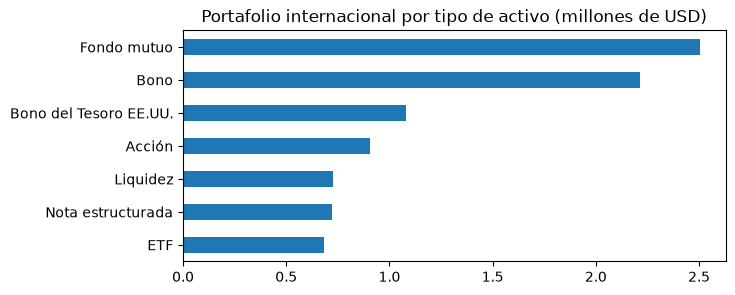

In [19]:
def tipo_activo(fila):
    nombre = fila["nombre_activo"].upper()
    isin = fila["isin"]
    tiene_vencimiento = fila["fecha_vencimiento"] != "1/01/1900"

    if isin == "Liquidez" or nombre == "CASH":
        return "Liquidez"
    if "LKD" in nombre or "LNKD" in nombre:
        return "Nota estructurada"
    if tiene_vencimiento and "TREAS" in nombre:
        return "Bono del Tesoro EE.UU."
    if tiene_vencimiento:
        return "Bono"
    if "ETF" in nombre or "ISHARES" in nombre or "SPDR" in nombre or "VANGUARD" in nombre:
        return "ETF"
    if isin.startswith("LU") or isin.startswith("IE"):
        return "Fondo mutuo"
    return "Acción"

u["tipo"] = u.apply(tipo_activo, axis=1)

ultima = u.groupby("id_sistema_cliente")["fecha"].transform("max")
foto_usd = u[u["fecha"] == ultima].copy()
print("Fecha:", foto_usd["fecha"].max().date(), "| clientes:", foto_usd["id_sistema_cliente"].nunique(),
      "| posiciones:", len(foto_usd), "| total USD:", round(foto_usd["valor"].sum()))

t = foto_usd.groupby("tipo")["valor"].agg(posiciones="count", usd="sum").sort_values("usd", ascending=False)
t["porcentaje"] = (t["usd"] / t["usd"].sum() * 100).round(1)
display(t)

(t["usd"].sort_values() / 1e6).plot.barh(figsize=(7, 3), title="Portafolio internacional por tipo de activo (millones de USD)")
plt.ylabel("")
plt.show()

In [20]:
# posiciones que vencen más pronto después de la última fecha
con_vencimiento = foto_usd[foto_usd["fecha_vencimiento"] != "1/01/1900"].copy()
con_vencimiento["vencimiento"] = pd.to_datetime(con_vencimiento["fecha_vencimiento"], format="%m/%d/%Y")
con_vencimiento["dias"] = (con_vencimiento["vencimiento"] - foto_usd["fecha"].max()).dt.days
con_vencimiento["nombre_activo"] = con_vencimiento["nombre_activo"].str[:45]
con_vencimiento.sort_values("vencimiento")[["id_sistema_cliente", "tipo", "nombre_activo", "vencimiento", "dias", "valor"]].head(5)

,id_sistema_cliente,tipo,nombre_activo,vencimiento,dias,valor
3484,10026419826,Nota estructurada,UBS AG LKD TO INDU SPX NDX ISIN#CH1234256894,2024-06-06,7,"114,690.00"
1753,10021382511,Nota estructurada,BNP PARIBAS LNKD TO NDX SPX INDU ISIN#XS24848,2024-09-16,109,"56,350.00"
1609,10014876058,Bono,BANCOLOMBIA PANAMA SA BOND 6.100% 11/13/24 RE,2024-11-13,167,"50,088.50"
3489,10032184607,Nota estructurada,BNP PARIBAS ISSUANCE B V LKD TO DJ INDUSTR AV,2024-12-09,193,"55,130.00"
3473,10026419826,Nota estructurada,BNP PARIBAS ISSUANCE B V LKD TO DJ INDUSTR AV,2024-12-09,193,"55,130.00"


**Lo que veo:**
- Al 30 de mayo de 2024 hay 12 clientes con unos 8,8 millones de dólares, repartidos entre fondos, bonos, acciones, ETFs, liquidez y notas estructuradas.
- Hay posiciones que vencen muy cerca de la última fecha (una nota estructurada vence a los 7 días). Eso también le sirve al gerente comercial para saber a quién buscar.

## 5. Local + internacional

Para sumar los dos portafolios paso los dólares a pesos con la TRM del 30 de mayo de 2024 (3.867,02 según datos.gov.co). Las fechas de corte no son iguales: el local llega hasta el 15 de mayo y el internacional hasta el 30 de mayo.

In [21]:
TRM = 3867.02

local = foto.groupby("id_sistema_cliente")["aba_corregido"].sum() / 1e6
internacional = foto_usd.groupby("id_sistema_cliente")["valor"].sum() * TRM / 1e6
total = pd.DataFrame({"local_millones": local, "internacional_millones": internacional}).fillna(0)
total["total_millones"] = total["local_millones"] + total["internacional_millones"]
total = total.join(foto.groupby("id_sistema_cliente")[["banca", "perfil"]].first())

print("Local:", round(total["local_millones"].sum()), "millones de COP")
print("Internacional:", round(total["internacional_millones"].sum()), "millones de COP")
print("El internacional es el", round(total["internacional_millones"].sum() / total["total_millones"].sum() * 100),
      "% del total")

total[total["internacional_millones"] > 0].sort_values("total_millones", ascending=False)

Local: 5096 millones de COP
Internacional: 34149 millones de COP
El internacional es el 87 % del total


,local_millones,internacional_millones,total_millones,banca,perfil
id_sistema_cliente,,,,,
10014876058,8.70,"8,698.39","8,707.09",Personal,SIN DEFINIR
1004870235,7.68,"6,574.92","6,582.60",Personal,AGRESIVO
10026419826,0.10,"6,134.07","6,134.16",Personal,SIN DEFINIR
10041560001,1.16,"4,518.32","4,519.48",Personal,SIN DEFINIR
10021382511,2.32,"2,730.81","2,733.13",Personal,SIN DEFINIR
10038643094,87.00,"2,218.76","2,305.75",Personal,SIN DEFINIR
10020203023,"1,829.95",283.00,"2,112.95",Privada,MODERADO
10032184607,61.91,"1,056.04","1,117.95",Personal,MODERADO
10039538018,0.34,876.34,876.68,Personal,MODERADO


**Lo que veo:**
- El portafolio internacional pesa mucho más que el local (cerca del 87% del total). Si uno mira solo el local se lleva una idea equivocada del cliente.
- Hay clientes que en lo local tienen muy poco pero afuera tienen más de un millón de dólares, y varios están en Banca Personal y con perfil SIN DEFINIR. Esto es lo que quiero revisar en el modelo del punto 4: si el riesgo que de verdad tiene el portafolio va de acuerdo con el perfil del cliente.

## 6. Resumen de problemas y qué voy a hacer en SQL

| Archivo | Problema | Qué hago |
|---|---|---|
| Los dos históricos | Filas duplicadas exactas (cerca del 10%) | Quitarlas con `DISTINCT` |
| Los dos históricos | Pocas filas con valores corridos o campos vacíos | Pasarlas a una tabla de rechazadas |
| catalogo_banca | `PR` repetido | `DISTINCT` |
| catalogo_activos | CEMARGOS repetido y PFCEMARGOS con código 1115 | Dejar 1003 y corregir a 1015 |
| macroactivos | `10007` es `1007` (Fiducuenta) | Unificar el código antes de quitar repetidos |
| macroactivos | IDs en notación científica | Se dejan así (limitación) |
| macroactivos | ID `1002203023` mal digitado | Corregir a `10020203023` |
| macroactivos | Activos `1022` y `None` sin catálogo | Mostrarlos como "No identificado" |
| macroactivos | Valores duplicados o sin un dígito un solo día | Corregirlos comparando con el día anterior y el siguiente |
| internacional | `None`, `nan`, espacios y fecha `1/01/1900` | Dejar vacío (`NULL`) y quitar espacios |
| internacional | La carga del 1 de marzo trae cada posición muchas veces | Usar solo la última carga de cada cliente |